# EDA to Prediction (DieTanic)

## Contents of the Notebook:

### part1: Exploratory Data Analysis(EDA):
1)Analysis of the features.

2)Finding any relations or trends considering multiple features.

### part2: Feature Engineering and Data Cleaning:
1)Adding any few features.

2)Removing redundant features.

3)Converting features into suitable form for modeling.

### part3: Predictive Modeling
1)Running Basic Algorithms.

2)Cross Validation.

3)Ensembling.

4)Important Features Extraction.

## part1: Exploratory Data Analysis(EDA)

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn')

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

sns.set(font_scale=1.3)

In [2]:
data=pd.read_csv('../input/titanic/train.csv')

In [3]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
data.isnull().sum() #checking for total null values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

The Age,Cabin and Embarked have null values, I will try to fix them.

### How many Survived??

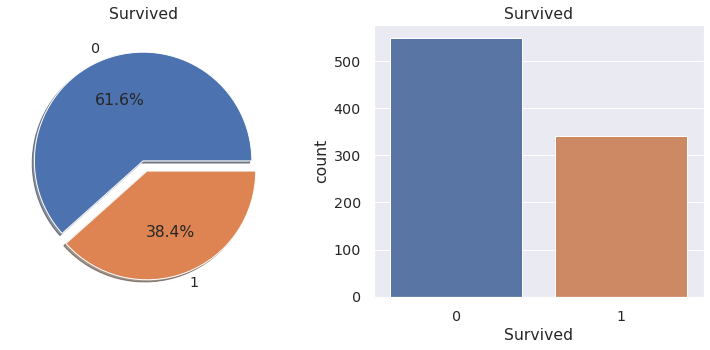

In [5]:
f,ax=plt.subplots(1,2,figsize=(13,5))
data['Survived'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('Survived')
ax[0].set_ylabel('')

sns.countplot('Survived', data=data, ax=ax[1])
ax[1].set_title('Survived')
plt.show()

It is evident that not many passengers survived the accident.

Out of 891 passengers in training set, only around 350 survived i.e Only 38.4% of the total training set survived the crash. We need to dig down more to get better insights from the data and see which categories of the passengers did survived and who didn't.

We will try to check the survived rate by using the different features of the dataset. Some of the features being Sex, Port Of Embarcation, Age,etc.

First let us understand the different types of features.

## Types Of Features

### Categorical Features:

A categorical variable is one that has two or more categories and each value in that feature can be categorised by them. For example, gender is a categorical variable having two categories (male and female). Now we cannot sort or give any ordering to such variables. They are also known as **Nominal Varialbes**.

카테고리 데이터는 순서가 없다. 그래서 라벨 인코딩을 하면 1,2,3으로 우위가 생겨서 **데이터에 왜곡**이 생긴다. 따라서 라벨인코딩 후 **원핫인코딩, 빈도 인코딩, 평균 인코딩**을 사용한다. 

**Categorical Features in the dataset: Sex, Embarked.**

### Ordinal Features:

An ordinal variable is similar to categorical values, but the difference between them is that we can have relative ordering or sorting between the values. For eg:If we have a feature like **Height** with values **Tall, Medium, Short**, then Height is a ordinal variable. Here we can have a relative sort in the variable.

순서가 있기 때문에 정렬을 할 수 있다. **라벨 인코딩만 사용**하면 된다.

**Ordinal Features in the dataset:Pclass**

### Continous Feature:

A feature is said to be continous if it can take values between any two points or between the minimum or maximum values in the features column.

연속형은 한 피쳐안에 범위가 존재한다. 그래서 최소값과 최대값이 있고 데이터는 그 사이에 분포하게 된다. 따라서 데이터의 범위를 나눌 수 있다. 

**Continous Features in the dataset: Age**

그래프를 그릴 때 데이터 타입을 잘 고려해야 한다. 각 데이터가 어떤 타입인지 알고 거기에 맞는 그래프를 사용해야 유의미한 통찰을 얻을 수 있다.

## Analysing The Features

## Sex -> Categorical Feature

In [6]:
data.groupby(['Sex', 'Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

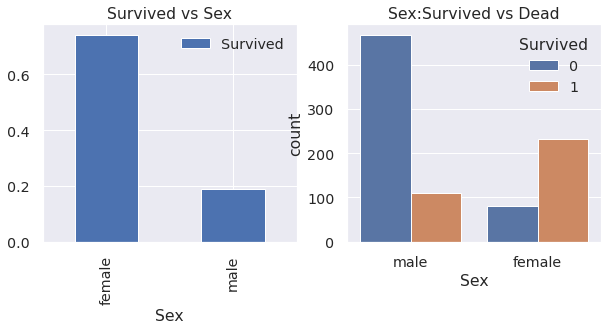

In [7]:
f,ax=plt.subplots(1,2,figsize=(10,4))
data[['Sex', 'Survived']].groupby(['Sex']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survived vs Sex')
sns.countplot('Sex', hue='Survived', data=data, ax=ax[1])
ax[1].set_title('Sex:Survived vs Dead')
plt.show()

This looks interesting. The number of men on the ship is lot more than the number of women. Still the number of women saved is almost twice the number of males saved. The survival rates for a **women on the ship is around 75% while that for men in around 18-19%.**

This looks to be a **very important** feature for modeling. But is it the best?? Lets check other features.

## Pclass -> Ordinal Feature

In [8]:
pd.crosstab(data.Pclass,data.Survived,margins=True).style.background_gradient(cmap='summer_r')

Survived,0,1,All
Pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


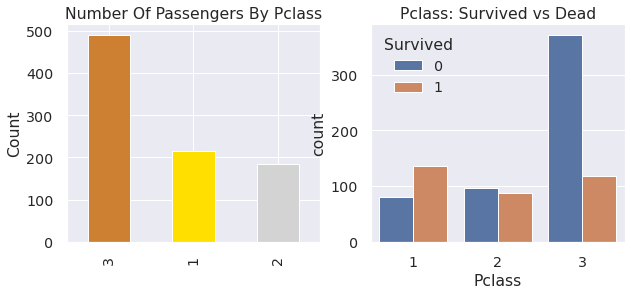

In [9]:
f, ax=plt.subplots(1,2,figsize=(10,4))
data['Pclass'].value_counts().plot.bar(color=['#CD7F32', '#FFDF00', '#D3D3D3'],ax=ax[0])
ax[0].set_title('Number Of Passengers By Pclass')
ax[0].set_ylabel('Count')
sns.countplot('Pclass', hue='Survived', data=data, ax=ax[1])
ax[1].set_title('Pclass: Survived vs Dead')
plt.show()

People say **Money Can't Buy Everthing.** But we can clearly see that Passengers Of Pclass 1 were given a very high priority while rescue.
Even though the number of Passengers in Pclass 3 were a lot higher, still the number of survived from them is very low, somewhere around **25%**.

For Pclass1 Survived is around **63%** while for Pclass2 is around **48%**. So money and status matters. Such a materialistic world.

Lets Dive in little bit more and check for other interesting observation. Lets check survival rate with **Sex and Pclass** Together.

In [10]:
pd.crosstab([data.Sex,data.Survived], data.Pclass,margins=True).style.background_gradient(cmap='summer_r')

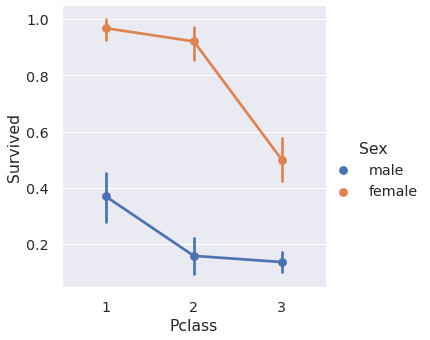

In [11]:
sns.factorplot('Pclass','Survived',hue='Sex',data=data)
plt.show()

We use **FactorPlot** in this case, because they make the seperation of categorical values easy.

Looking at the **CrossTab** and the **FactorPlot**, we can easily infer that survival for **Women from Pclass1** is about **95-96%**,as only 3 out of 94 Women from Pclass1 died. 

It is evident that irrespctive of Pclass, Women were given first priority while rescue. Even Men from Pclass1 have a very low survival rate.

Looks like Pclass is also an important feature. Let's analyse other features.

에러바가 작은 점이 신뢰도가 높다. 그만큼 많은 데이터를 대변한다는 뜻이다. 카테고리 데이터 성별과 생존여부, 오디널 데이터인 클래스를 가지고 그래프를 그렸다.

## Age -> Continous Feature

In [12]:
print('Oldest Passenger was of:',data['Age'].max(),'Years')
print('Youngest Passenger was of:',data['Age'].min(),'Years')
print('Average Age on the ship:', data['Age'].mean(), 'Years')

Oldest Passenger was of: 80.0 Years
Youngest Passenger was of: 0.42 Years
Average Age on the ship: 29.69911764705882 Years


In [13]:
data['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

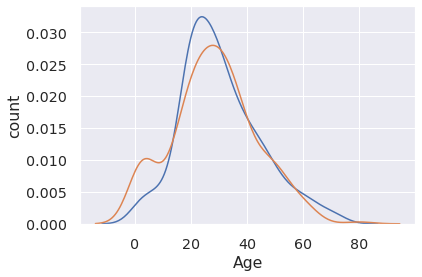

In [14]:
# 생존/사망자 별 나이분포
sns.kdeplot(data.loc[data['Survived'] == 0, 'Age'], label='dead')
sns.kdeplot(data.loc[data['Survived'] == 1, 'Age'], label='survived')
plt.ylabel('count')
plt.show()

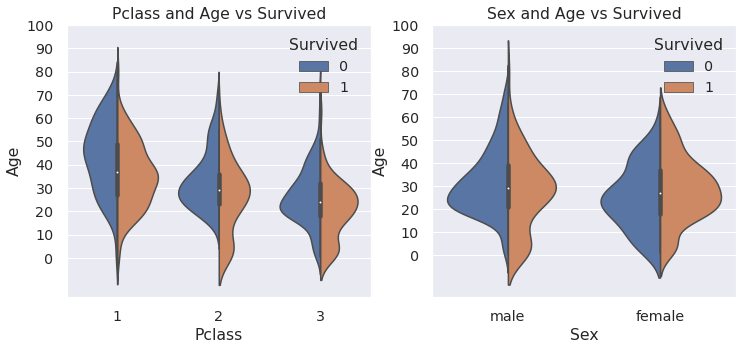

In [15]:
f, ax = plt.subplots(1,2,figsize=(12,5))

sns.violinplot('Pclass', 'Age', hue='Survived', data=data, split=True, ax=ax[0])
ax[0].set_title('Pclass and Age vs Survived')
ax[0].set_yticks(range(0,110,10)) # 가로줄의 범위와 간격

sns.violinplot('Sex','Age', hue='Survived', data=data, split=True, ax=ax[1])
ax[1].set_title('Sex and Age vs Survived')
ax[1].set_yticks(range(0,110,10))
plt.show()

### Observations:

1) The number of children increases with Pclass and the survival rate for passengers below Age 10(i.e children) looks to be good irrespective of the Pclass.

2) Survival chances for Passengers aged 20-50 from Pclass1 is high and is even better for Women.

3) For males, the survival chances decrease with an increase in age.

As we had seen earlier, the Age feature has **177** null values. To replace these NaN values, we can assign them the mean age of the dataset. 

But the problem is, there were many people with many different ages. We just can't assign a 4 year kid with the mean age that is 29 years. Is there any way to find out what age-band does the passenger lie??

**Bingo!!!!**, we can check the **Name** feature. Looking upon the feature, we can see that the names have a salutation like Mr or Mrs. Thus we can assign the mean values of Mr and Mrs to the respective groups. 

**"What's In A Name??" -----> Feature** :p

이런식으로 빈데이터를 다루는 여러가지 방법이 있다. 평균이나 중앙값을 이용할 수도 있고 대세를 따라갈 수도 있다. 하지만 최대한 실제에 가까운 값을 도출하는 방법을 탐구해봐야 한다. 여기서는 이름에 들어가는 호칭을 뽑아서 그 호칭별 평균 나이를 이용해서 해당 호칭을 가진 샘플의 빈 나이값을 채운다. 

이렇게 데이터를 조작하면서 서로 상관관계를 비교해가면서 새로운 특성을 뽑아내서 이용할 수 있다. 목적에 맞는 방법을 잘 이용할 수록 좋다.

In [16]:
data['Initial'] = 0
for i in data:
    data['Initial']=data.Name.str.extract('([A-Za-z]+)\.')
# lets extract the Salutations

Okay so here we are using the Regex: **[A-Za-z]+)..** So what it does is, it looks for strings which lie between **A-Z or a-z** and followed by a **.(dot)**. So we successfully extract the Initials from the Name.

In [17]:
pd.crosstab(data.Initial,data.Sex).T.style.background_gradient(cmap='summer_r')
# Checking the Initials with the Sex

Initial,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Sex,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


Okay so there are some misspelled Initials like Mlle or Mme that stand for Muss. I will replace them with Miss and same thing for other values.

In [18]:
data['Initial'].replace(['Mlle','Mme', 'Ms',   'Dr', 'Major','Lady','Countess','Jonkheer','Col',  'Rev',  'Capt','Sir','Don'], 
                        ['Miss','Miss','Miss', 'Mr', 'Mr',   'Mrs', 'Mrs',     'Other',   'Other','Other','Mr',  'Mr', 'Mr'],inplace=True)

In [19]:
data.groupby('Initial')['Age'].mean() 
# Let's check the average age by Initials

Initial
Master     4.574167
Miss      21.860000
Mr        32.739609
Mrs       35.981818
Other     45.888889
Name: Age, dtype: float64

### Filling NaN Ages

In [20]:
# Assigning the NaN Values with the Ceil values of the mean ages
data.loc[(data.Age.isnull())&(data.Initial=='Mr'),"Age"]=33
data.loc[(data.Age.isnull())&(data.Initial=='Mrs'),'Age']=36
data.loc[(data.Age.isnull())&(data.Initial=='Master'),'Age']=5
data.loc[(data.Age.isnull())&(data.Initial=='Miss'),'Age']=22
data.loc[(data.Age.isnull())&(data.Initial=='Other'), 'Age']=46

In [21]:
data.Age.isnull().any()
# So no null values left finally

False

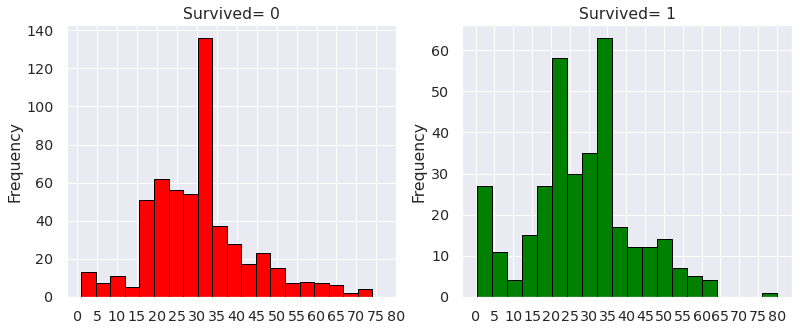

In [22]:
f,ax = plt.subplots(1,2,figsize=(13,5))

data.loc[data['Survived']==0, 'Age'].plot.hist(ax=ax[0],bins=20,edgecolor='black', color='red')
ax[0].set_title('Survived= 0')
x1=list(range(0,85,5))
ax[0].set_xticks(x1)

data.loc[data['Survived']==1, 'Age'].plot.hist(ax=ax[1],color='green',bins=20,edgecolor='black')
ax[1].set_title('Survived= 1')
x2=list(range(0,85,5))
ax[1].set_xticks(x2)
plt.show()

### Observations:

1) The Toddlers(age<5) were saved in large nembers(The Women and Child First Policy).

2) The oldest Passenger was saved(80 years).

3) Maximum number of deaths were in the age group of 30-40.

## 캐글 팁!

새로운 피쳐를 만들고 나서 꼭 CV를 해서 모델의 성능이 올라가는지를 확인해봐야 한다. 향상되면 사용하고 아니라면 버린다. 

캐글에서 점수를 잘 받으려면 CV시스템을 잘 갖춰놔야 한다. 좋은 CV시스템은 CV점수와 LB(리더보드)점수가 선형적으로 움직여서 리더보드에 직접 제출해보지 않아도 대략 리더보드 점수를 예측할 수 있다. LB제출은 제한이 있기 때문에 좋은 CV시스템을 갖추는 것이 매우 중요하다. FE는 좋은 CV시스템을 갖춰서 cv점수의 신뢰도가 높아진 후에 하는 것이다. CV점수가 실제 점수를 반영하지 않는다면 아무리 fe를 해도 크게 의미가 없기 때문이다.

좋은 CV시스템은 각각의 폴드마다 점수를 평균했을 때 평균과의 표준편차가 작고 CV스코어와 LB점수와 선형적일 수록 좋다.

대회 초반의 LB제출은 좋은 CV시스템을 만들기 위한 과정이다.

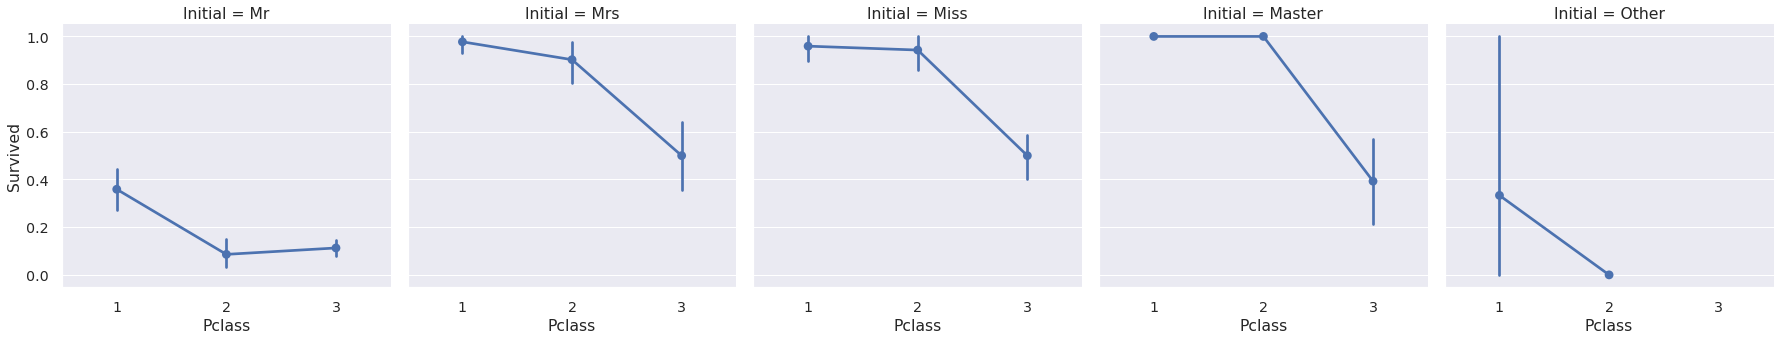

In [23]:
sns.factorplot('Pclass','Survived', col='Initial', data=data)
plt.show()

The Women and Child first policy thus holds true irrespective of the class.

hue는 색으로 나눠주고 col은 특성마다 그래프를 그려준다.

## Embarked -> Categorical Value

In [24]:
pd.crosstab([data.Embarked, data.Pclass], [data.Sex, data.Survived], 
            margins=True).style.background_gradient(cmap='summer_r')

### Chances for Survival by Port Of Embarkation

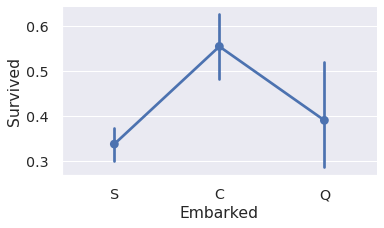

In [25]:
sns.factorplot('Embarked', 'Survived', data=data)
fig=plt.gcf()
fig.set_size_inches(6,3)
plt.show()

The chances for survival for Port C is highest around 0.55 while it is lowest for S.

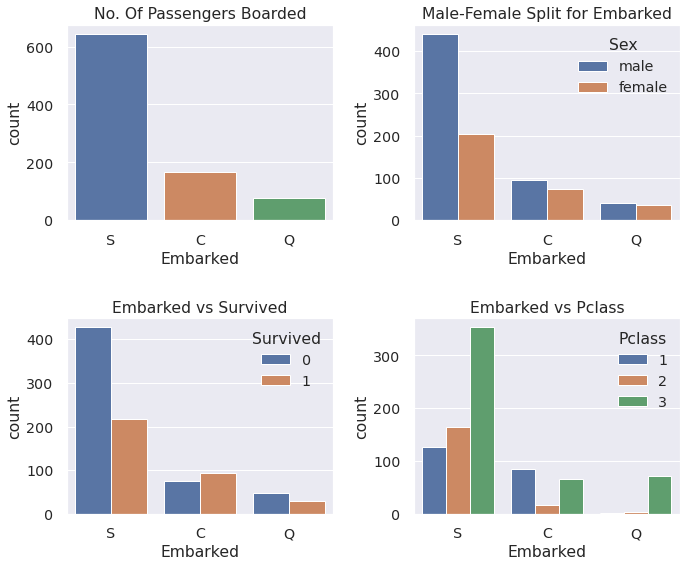

In [26]:
f, ax=plt.subplots(2,2,figsize=(11,9))
sns.countplot('Embarked', data=data, ax=ax[0,0])
ax[0,0].set_title('No. Of Passengers Boarded')
sns.countplot('Embarked',hue='Sex', data=data, ax=ax[0,1])
ax[0,1].set_title('Male-Female Split for Embarked')
sns.countplot('Embarked', hue='Survived',data=data, ax=ax[1,0])
ax[1,0].set_title('Embarked vs Survived')
sns.countplot('Embarked', hue='Pclass', data=data, ax=ax[1,1])
ax[1,1].set_title('Embarked vs Pclass')
plt.subplots_adjust(wspace=0.3, hspace=0.5)
plt.show()

### Observations:

1) Maximum passengers boarded from S. Majority of them being from Pclass3.

2) The Passengers from C look to be lucky as a good proportion of them survived. The reason for this maybe the rescue of all the Pclass1 and Pclass2 Passengers.

3) The Embark S looks to the port from where majority of the rich people boarded. Still the chances for survival is low here, that is because many passengers from Pclass3 around 81% didn't survive.

4) Port Q had almost 95% of the passengers were from Pclass3.

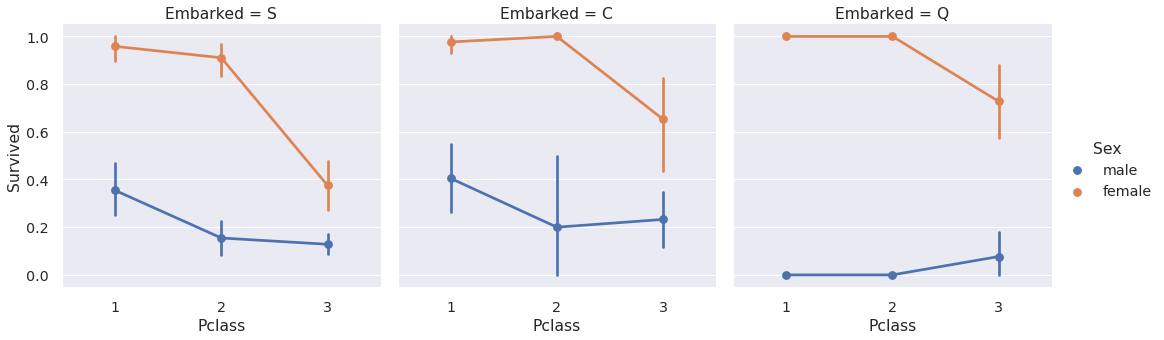

In [27]:
sns.factorplot('Pclass', 'Survived', hue='Sex', col='Embarked', data=data)
plt.show()

### Observations:

1) The survival chances are almost 1 for women for Pclass1 and Pclass2 irrespective of the Pclass.

2) Port S looks to be very unlucky for Pclass3 Passengers as the survival rate for both men and women is very low.**(Money Matters)**

3) Port Q looks to be unluckiest for Men, as almost all were from Pclass3.

### Filling Embarked NaN

As we saw that maximum passengers boarded from Port S, we replace NaN with S.

승선지 결측치를 채울 때는 다른 기준이 없기 때문에 대부분의 사람들이 탄 S로 채워준다.

In [28]:
for e in data['Embarked'].unique():
    print('승선지가 {}인 탑승객 비율 : {:.2f}%'.format(e, 100 * data.loc[data['Embarked'] == e].shape[0] / data['Embarked'].shape[0]))

승선지가 S인 탑승객 비율 : 72.28%
승선지가 C인 탑승객 비율 : 18.86%
승선지가 Q인 탑승객 비율 : 8.64%
승선지가 nan인 탑승객 비율 : 0.00%


In [29]:
data['Embarked'].fillna('S', inplace=True)

In [30]:
data.Embarked.isnull().any()
# Finally No NaN values

False

## SibSp -> Discrete Feature

This feature represents whether a person is alone or with his family members.

Sibling = brother, sister, stepbrother, stepsister

Spouse = husband, wife

In [31]:
pd.crosstab(data['SibSp'],data['Survived']).style.background_gradient(cmap='summer_r')

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


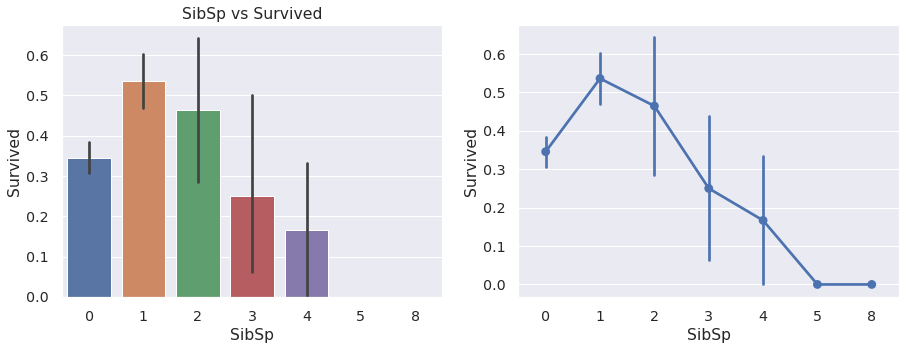

In [32]:
f,ax=plt.subplots(1,2,figsize=(15,5))
sns.barplot('SibSp','Survived',data=data, ax=ax[0])
ax[0].set_title('SibSp vs Survived')
sns.pointplot('SibSp','Survived',data=data, ax=ax[1])
ax[0].set_title('SibSp vs Survived')
plt.close(2)
plt.show()

In [33]:
pd.crosstab(data['SibSp'], data['Pclass']).style.background_gradient(cmap='summer_r')

Pclass,1,2,3
SibSp,,,
0,137,120,351
1,71,55,83
2,5,8,15
3,3,1,12
4,0,0,18
5,0,0,5
8,0,0,7


### Observations:

The barplot and factorplot shows that if a passenger is alone onboard with no siblings, he have 34.5% survival rate. The graph roughly decreases if the nember of siblings incerese. This makes sense. That is, if I have a family on board, I will try to save them instead of saving myself first. Surprisingly the survival for families with 5-8 members is **0%**. The reason may be Pclass??

The reason is Pclass. The crosstab shows that Person with SibSp>3 were all in Pclass3. It is imminent that all the large families in Pclass3(>3) died.

## Parch

In [34]:
pd.crosstab(data.Parch,data.Pclass).style.background_gradient(cmap='summer_r')

Pclass,1,2,3
Parch,,,
0,163,134,381
1,31,32,55
2,21,16,43
3,0,2,3
4,1,0,3
5,0,0,5
6,0,0,1


The crosstab again shows that larger families were in Pclass3.

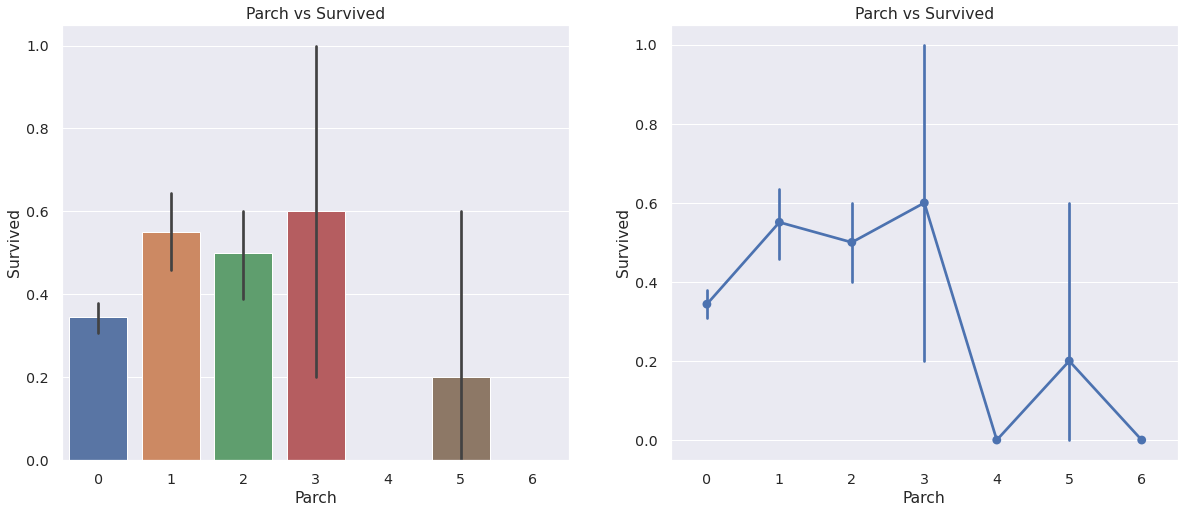

In [35]:
f, ax = plt.subplots(1,2,figsize=(20,8))
sns.barplot('Parch','Survived',data=data, ax=ax[0])
ax[0].set_title('Parch vs Survived')

sns.pointplot('Parch', 'Survived', data=data, ax=ax[1])
ax[1].set_title('Parch vs Survived')

plt.close(2)
plt.show()

## Observations:

Here too the results are quite similar. Passengers with their parants onboard have greater chance of survival. It however reduces as the number goes up.

The chances of survival is good for somebody who has 1-3 parents on the ship. Being alone also proves to be fatal and the chances for survival decreases when somebody has >4 parents on the ship.

### 새로운 피쳐 만드는 팁

두 가지 피쳐를 하나로 합칠 수 있다. 

In [36]:
# data['new_cat_pclass_sex'] = data['Pclass'].astype(str) + '_' + data['Sex'].astype(str)

In [37]:
# data.groupby('new_cat_pclass_sex')['Survived'].mean().plot.bar()

## Fare -> Continous Feature

In [38]:
print('Highest Fare was:', data['Fare'].max())
print('Lowest Fare was:', data['Fare'].min())
print('Average Fare was:', data['Fare'].mean())

Highest Fare was: 512.3292
Lowest Fare was: 0.0
Average Fare was: 32.2042079685746


The lowest fare is **0.0**. Wow!! a free luxurious ride.

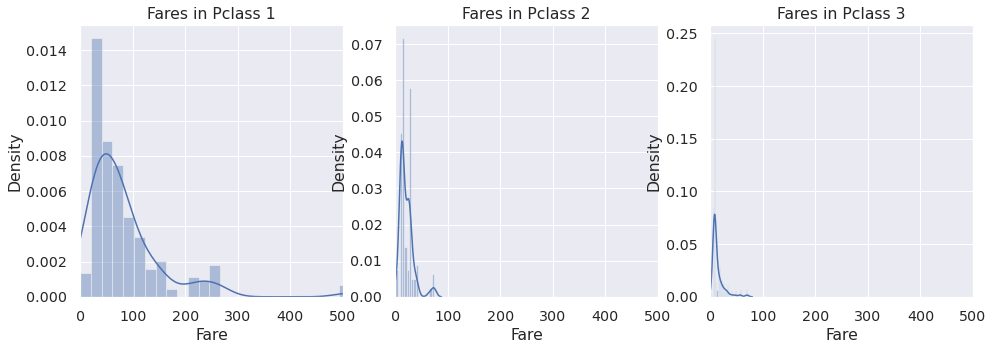

In [39]:
f,ax=plt.subplots(1,3,figsize=(16,5))
sns.distplot(data[data['Pclass']==1].Fare,ax=ax[0])
ax[0].set_title('Fares in Pclass 1')
ax[0].set_xlim([0, 500]) # 같은 스케일로 비교하기 위해서
sns.distplot(data[data['Pclass']==2].Fare,ax=ax[1])
ax[1].set_title('Fares in Pclass 2')
ax[1].set_xlim([0, 500])
sns.distplot(data[data['Pclass']==3].Fare,ax=ax[2])
ax[2].set_title('Fares in Pclass 3')
ax[2].set_xlim([0, 500])
plt.show()

There looks to be a large distribution in the fares of Passengers in Pclass1 and this distribution goes on decreasing as the standards reduces. As this is also continous, we can convert into discrete values by using binning.

## Observations in a Nutshell for all features:

**Sex**: The chance of survival for women is high as compared to men.

**Pclass**: There is a visible trend that being a **1st class Passenger** gives you better chances of survival. The survival rate for **Pclass3 is very low**. For **women**, the chance of survival from **Pclass1** is almost 1 and is high too for those from **Pclass2. Money Wins!!!.**

**Age**: Chlidren less than 5-10 years do have a high chance of survival. Passengers between age group 15 to 35 died a lot.

**Embarked**: This is a very interesting feature. **The chances of survival at C looks to be better than even though the majority of Pclass1 passengers got up at S.** Passengers at Q were all from **Pclass3**.

**Parch+SibSp**: Having 1-2 siblings,spouse on board or 1-3 Parents shows a greater chance of probablity rather than being alone or having a large family travelling with you.

## Correlation Between The Features

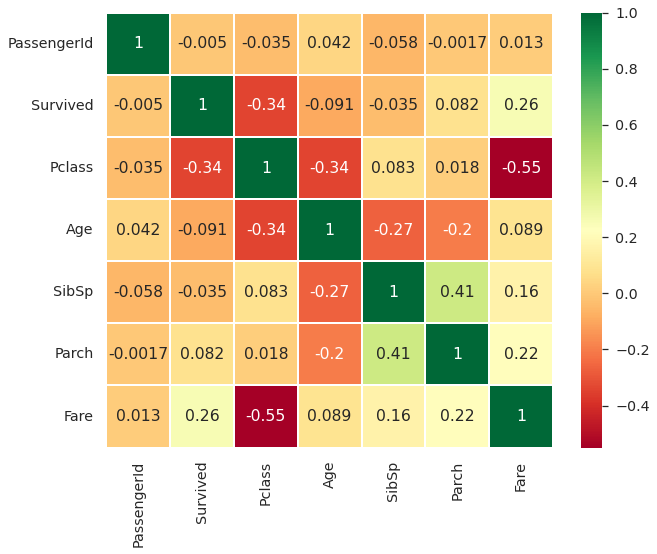

In [40]:
sns.heatmap(data.corr(), annot=True, cmap='RdYlGn',linewidths=0.2)
# data.corr() --> correlation matrix
fig=plt.gcf()
fig.set_size_inches(10,8)
plt.show()

## Interpreting The Heatmap

The first thing to note is that only the numeric features are compared as it is obvious that we cannot correlate between alphabets or strings. Before understanding the plot, let us see what exactly correlation is.

**POSITIVE CORRELATION**: If an **increase in feature A leads to increase in feature B, then they are positively correlated.** A value **1 means perfect positive correlation**.

**NEGATIVE CORRELATIONS**: If an **increase in feature A leads to decrease in feature B, then they are negatively correlated**. A value **-1 means perfect negative correlation**.

Now lets say that two features are highly or perfectly correlated, so the increase in one leads to increase in the other. This means that both the features are containing highly similar information and there is very little or no variance in information. This is known as **MultiColinearity** as both of them contains almost the same information.

So do you think we should use both of them as **one of them is redundant**. While making or training models, we should try to eliminate redundant features as it reduces training time and many such advantages.

부스트 모델의 경우 다양한 피쳐의 트리를 만들어서 모델의 성능을 높이는데 피쳐가 중복된다면 의미가 없는 행동이된다. 그렇기 때문에 다중공선성이 높은 피쳐는 빼는 것이 좋다. 

Now from the above heatmap, we can see that the features are not much correlated. The highest correlation is between **SibSp and Parch i.e 0.41**. So we can carry on with all features.


여기서는 타겟값이 이진분류이지만 만약 타겟이 연속형 데이터라면 상관관계 분석에서 타겟값과 상관도가 높은 피쳐를 찾는다면 모델의 성능이 높아질 수 있다. 이렇게 피쳐들간의 상관관계를 분석해서 상관성이 높은 피쳐는 제거하고 타겟과 상관도가 높은 피쳐를 찾는다.

## Part2: Feature Engineering and Data Cleaning

Now what is Feature Engineering?

Whenever we are given a dataset with features, it is not necessary that all the features will be important. There maybe many redundant features which should be eliminated. Also we can get or add new features by observing or extracting information from other features.

An example would be getting the Initials feature using the Name Feature. Lets see if we can get any new features and eliminate a few. Also we will tranform the existing relevant features to suitable form for Predictive Modeling.

## Age_band

Problem With Age Feature:
As I have mentioned earlier that **Age is a continous feature**, there is a problem with Continous Variables in Machine Learning Models.

**Eg**: If I say group or arrange Sports Person by **Sex**, We can easily segregate them by Male and Female.

Now if I say to group them by their **Age**, then how would you do it? If there are 30 Persons, there may be 30 age values. Now this is problematic.

We need to convert these **continous values into categorical values** by either Binning or Normalization. I will be using binning i.e group a range of ages into a single bin or assign them a single value. 

Okay so the maximum age of a passenger was 80. So let's divide the range from 0-80 into 5 bins. So 80/5=16. So bins of size 16.

In [41]:
data['Age_band'] = pd.cut(data['Age'], 5)
data['Age_band'].value_counts()

(16.336, 32.252]    382
(32.252, 48.168]    325
(0.34, 16.336]      104
(48.168, 64.084]     69
(64.084, 80.0]       11
Name: Age_band, dtype: int64

In [42]:
data['Age_band']=0
data.loc[data['Age']<=16, 'Age_band']=0
data.loc[(data['Age']>16)&(data['Age']<=32), 'Age_band']=1
data.loc[(data['Age']>32)&(data['Age']<=48), 'Age_band']=2
data.loc[(data['Age']>48)&(data['Age']<=64), 'Age_band']=3
data.loc[data['Age']>64, 'Age_band']=4
data.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial,Age_band
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2


In [43]:
data['Age_band'].value_counts().to_frame().style.background_gradient(cmap='summer')
# checking the number of passengers in each band

,Age_band
1,382
2,325
0,104
3,69
4,11


새로 만든 피쳐를 가지고 그래프를 그려서 나이구간별 생존률을 클래스에 따라 확인해본다.

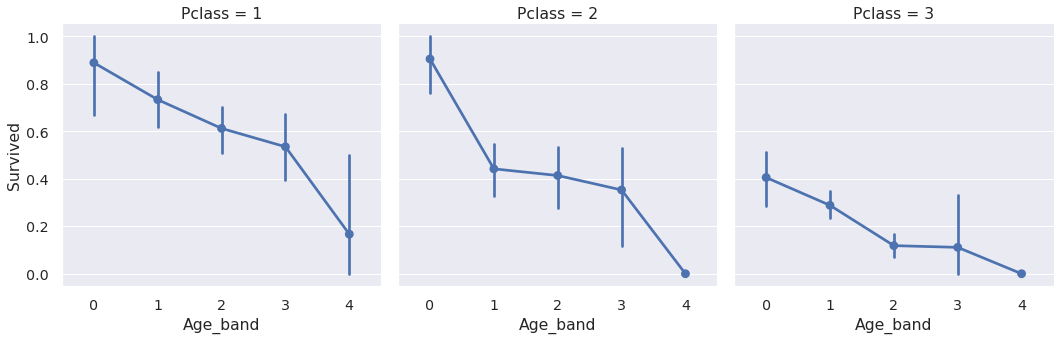

In [44]:
sns.factorplot('Age_band','Survived', data=data, col='Pclass')
plt.show()

True that..the survival rate decreases as the age increases irrespective of the Pclass.

## Family_Size and Alone

At this point, we can create a new feature called "Family_size" and "Alone" and analyse it. This feature is the summation of Parch and SibSp. It gives us a combined data so that we can check if survival rate have anything to do with family size of the passengers. Alone will denote whether a passenger is alone or not.

In [45]:
data['Family_Size'] = data['Parch'] + data['SibSp']#family size
data['Alone'] = 0
data.loc[data.Family_Size==0,'Alone']=1#Alone

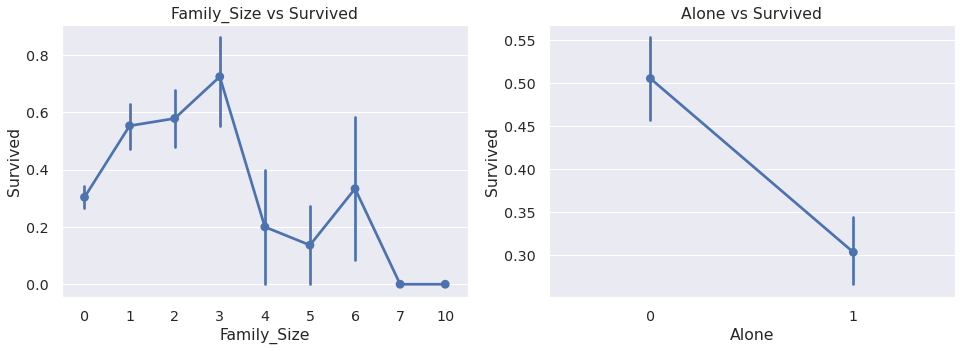

In [46]:
f,ax=plt.subplots(1,2,figsize=(16,5))
sns.pointplot('Family_Size','Survived',data=data,ax=ax[0])
ax[0].set_title('Family_Size vs Survived')
sns.pointplot('Alone','Survived',data=data,ax=ax[1])
ax[1].set_title('Alone vs Survived')
plt.close(2)
plt.close(3)
plt.show()

**Family_Size=0 means that the passenger is alone**. Clearly, if you are alone or family_size=0, then chances for survival is very low. For family size > 4, the chances decrease too. This alse looks to be an important feature for the model. Lets examine this further.

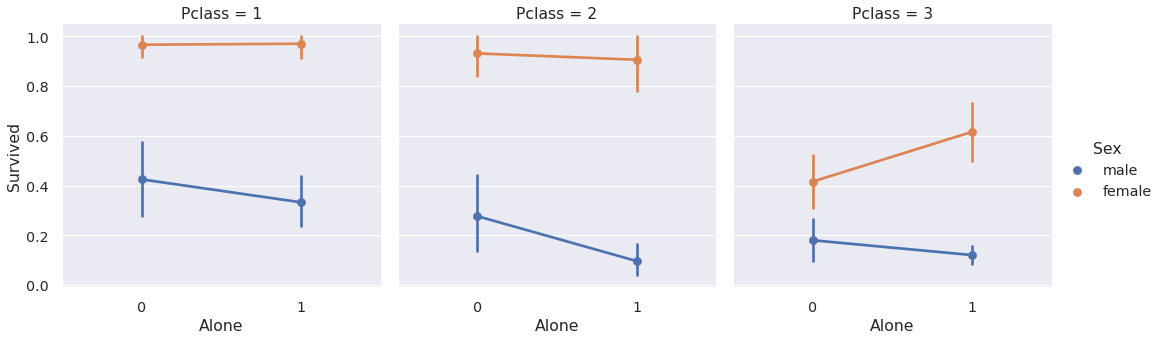

In [47]:
sns.factorplot('Alone','Survived', data=data, hue='Sex', col='Pclass')
plt.show()

It is visible that being alone is harmful irrespective of Sex or Pclass except for Pclass3 where the chances of females who are alone is high than those with family.



## Fare_Range

Since fare is also a continous feature, we need to convert it into ordinal value. For this we will use **pandas.qcut**.

So what **qcut** does is it splits or arranges the values according the nember of bins we have passed. So if we pass for 5 bins, it will arrange the values equally spaced into 5 seperate bins or value ranges.

In [48]:
data['Fare_Range']=pd.qcut(data['Fare'],4)
data.groupby(['Fare_Range'])['Survived'].mean().to_frame().style.background_gradient(cmap='summer_r')

,Survived
Fare_Range,
"(-0.001, 7.91]",0.197309
"(7.91, 14.454]",0.303571
"(14.454, 31.0]",0.454955
"(31.0, 512.329]",0.581081


In [49]:
data['Fare_Range'].value_counts()

(7.91, 14.454]     224
(-0.001, 7.91]     223
(14.454, 31.0]     222
(31.0, 512.329]    222
Name: Fare_Range, dtype: int64

qcut은 데이터를 원하는 개수의 그룹으로 분할해준다. 피쳐의 샘플을 원하는 개수로 나눠서 각 구간마다 동일한 샘플의 수가 담기게 된다. 

cut으로 나누게 되면 샘플의 수는 상관없이 구간의 간격을 같게해서 나눠준다. 위에서 나이 밴드는 cut으로 구간의 간격을 동일하게 잘라줬다. 

연속형 데이터를 구간으로 나눌 때 두 가지 모두 사용할 수 있는데 한 번 씩 나눠봐서 생존률이 어떻게 바뀌는지, 데이터를 신뢰할 수 있는지 판단해야 한다.

As discussed above, we can cleary see that as the **fare_range increases, the chances of survival increases**.

Now we cannot pass the Fare_Range values as it is. We should convert it into singleton values same as we did in **Age_Band**.

In [50]:
data['Fare_cat']=0
data.loc[data['Fare']<=7.91, 'Fare_cat']=0
data.loc[(data['Fare']>7.91)&(data['Fare']<=14.454), 'Fare_cat']=1
data.loc[(data['Fare']>14.454)&(data['Fare']<=31), 'Fare_cat']=2
data.loc[(data['Fare']>31)&(data['Fare']<=513), 'Fare_cat']=3

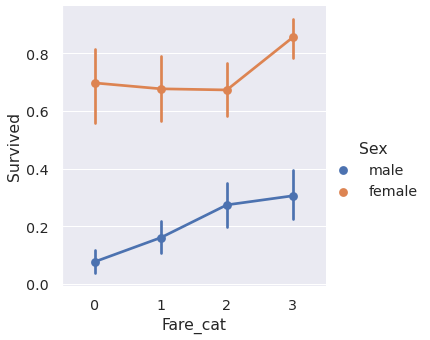

In [51]:
sns.factorplot('Fare_cat', 'Survived', data=data, hue='Sex')
plt.show()

Clearly, as the Fare_cat increases, the survival chances increases. This feature may become an important feature during modeling along with the Sex.

## Converting String Values into Numeric

Since we cannot pass strings to a machine learning model, we need to convert features loke Sex, Embarked, etc into numeric values.

In [52]:
# 유한님이 알려준 방식
from sklearn.preprocessing import LabelEncoder

for col in ['Sex', 'Embarked', 'Initial']:
    encoder = LabelEncoder()
    data[col] = encoder.fit_transform(data[col])

data.head()

# factorize를 사용할 수도 있다. 팩토라이저가 라벨인코더보다 속도가 빠르기 때문에 데이터가 많을 때는 팩토라이저를 사용하는 게 좋다.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial,Age_band,Family_Size,Alone,Fare_Range,Fare_cat
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,2,2,1,1,0,"(-0.001, 7.91]",0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,0,3,2,1,0,"(31.0, 512.329]",3
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,2,1,1,0,1,"(7.91, 14.454]",1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,2,3,2,1,0,"(31.0, 512.329]",3
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,2,2,2,0,1,"(7.91, 14.454]",1


In [53]:
# 커널에서 알려준 방식

# data['Sex'].replace(['male','female'],[0,1],inplace=True)
# data['Embarked'].replace(['S','C','Q'],[0,1,2],inplace=True)
# data['Initial'].replace(['Mr','Mrs','Miss','Master','Other'],[0,1,2,3,4],inplace=True)

## Dropping UnNeeded Features

**Name** -> We don't need feature as it cannot be converted into any categorical value. 

**Age** -> We have the Age_band feature, so no need of this.

**Ticket** -> It is any random string that cannot be categotised. 

특정문자를 추출하면 카테고리화 할 수 있다. 성능을 높이기 위해서 사용해본다.

**Fare** -> We have the Fare_cat feature, so unneeded.

**Cabin** -> A lot of NaN values and also many passengers have multiple cabins. So this is a useless feature. 

**Fare_Range** -> We have the fare_cat feature.

**PassengerId** -> Cannot be categoriosed.


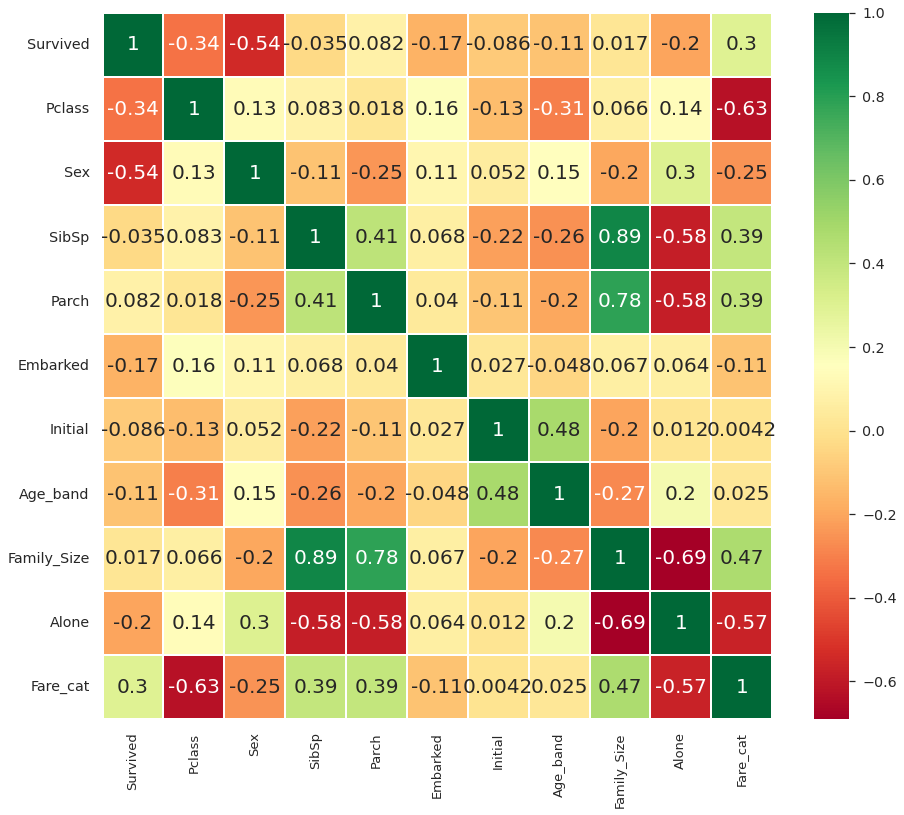

In [54]:
data.drop(['Name','Age','Ticket','Fare','Cabin','Fare_Range','PassengerId'], axis=1, inplace=True)
sns.heatmap(data.corr(),annot=True,cmap='RdYlGn', linewidths=0.2, annot_kws={'size':20})
fig=plt.gcf()
fig.set_size_inches(15,13)
plt.xticks(fontsize=13)
plt.xticks(fontsize=13)
plt.show()

Now the above correlation plot, we can see some positively related features. Some of them being **SibSp and Family_Size** and **Parch and Family_Size** and some negative ones like **Alone and Family_Size**. 

피쳐가 많아질 수록 피쳐를 잘 관리해야 한다. 리스트로 만들어서 저장하던지 아니면 데이터프레임으로 만들어서 설명도 넣고 csv파일로 저장한다. 아래에 예시

In [55]:
# categorical_features = ['Pclass', 'Sex', 'Age_cat']
# numerical_class = ['Age', 'Fare']

## Part3: Predictive Modeling

We have gained some insights from the EDA part. But with that, we cannot accurately predict or tell whether a passenger will survive or die. So new we will predict the whether the Passenger will survive or not using some great Classification Algorithms. Following are the algorithms I will use to make the model:

1) Logistic Regression

2) Support Vector Machines(Linear and radial)

3) Random Forest

4) K-Nearest Neighbours

5) Naive Bayes

6) Decision Tree

7) Logistic Regression

In [56]:
# importing all the required ML packages
from sklearn.linear_model import LogisticRegression # logistic regression
from sklearn import svm # support vector Machine
from sklearn.ensemble import RandomForestClassifier # Random Forest
from sklearn.neighbors import KNeighborsClassifier #KNN
from sklearn.naive_bayes import GaussianNB #Naive bayes
from sklearn.tree import DecisionTreeClassifier #Decision Tree
from sklearn.model_selection import train_test_split # traing and testing data split
from sklearn import metrics #accuracy measure
from sklearn.metrics import confusion_matrix # for confusion matrix

In [57]:
train, test = train_test_split(data,test_size=0.3, random_state=0, stratify=data['Survived'])
train_X=train[train.columns[1:]]
train_Y=train[train.columns[:1]]
test_X=test[test.columns[1:]]
test_Y=test[test.columns[:1]]
X=data[data.columns[1:]]
Y=data['Survived']

### Radial Support Vector Machines(rbf-SVM)



In [58]:
model=svm.SVC(kernel='rbf',C=1,gamma=0.1)
model.fit(train_X, train_Y)
prediction1=model.predict(test_X)
print('Accuracy for rbf SVM is ', metrics.accuracy_score(prediction1, test_Y))

Accuracy for rbf SVM is  0.835820895522388


### 프리딕션 가지고 놀기

In [59]:
prediction1

array([0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0])

위에서 모델이 예측한 결과를 살펴보면 0과 1로 이루어진 배열이다. 이 배열은 샘플이 0과 1일 확률을 계산하고 둘 중 우세한 한 쪽으로 결정된다. (49:51) 

In [60]:
model=svm.SVC(kernel='rbf',C=1,gamma=0.1, probability=True)
model.fit(train_X, train_Y)
prediction1=model.predict_proba(test_X)

In [61]:
prediction1[:3]

array([[0.85267022, 0.14732978],
       [0.3284997 , 0.6715003 ],
       [0.8568373 , 0.1431627 ]])

모델 객체를 생성할 때 probability를 사용하면 predict_proba함수를 사용할 수 있다. 이렇게 예측값을 뽑아보면 확률로 나타난 것을 확인할 수 있다. 이 확률을 가지고 위에서 본 0과 1의 배열로 만들 수 있다.

우리가 직접 기준을 가지고 0과 1로 나눌 수 있다. 두번째 확률이 70% 이상이여야 생존으로 본다면 아래처럼 쓸 수 있다.

In [62]:
(model.predict_proba(test_X)[:, 1] > 0.7).astype(int)

array([0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0])

사실 이 기준은 우리가 정하는 것이다. 이것도 하이퍼파라미터가 될 수 있다. threshold를 몇으로 잡아야 모델의 성능이 가장 높아지는지는 실험을 통해서 알 수 있다.

반복문으로 기준을 돌리면서 스코어를 저장해서 그래프로 확인할 수 있다. 프린트문을 넣어서 점수를 출력할 수도 있다.

In [63]:
model=svm.SVC(kernel='rbf',C=1,gamma=0.1, probability=True)
model.fit(train_X, train_Y)
score_array = []
for i in np.arange(0,1,0.01):
    prediction = (model.predict_proba(test_X)[:, 1] > i).astype(int)
    temp_score = 100 * metrics.accuracy_score(prediction, test_Y) 
    print(i, 'Accuracy for rbf SVM is {:.2f}%'.format(temp_score))
    score_array.append(temp_score)

0.0 Accuracy for rbf SVM is 38.43%
0.01 Accuracy for rbf SVM is 38.43%
0.02 Accuracy for rbf SVM is 38.43%
0.03 Accuracy for rbf SVM is 38.43%
0.04 Accuracy for rbf SVM is 38.43%
0.05 Accuracy for rbf SVM is 38.43%
0.06 Accuracy for rbf SVM is 38.43%
0.07 Accuracy for rbf SVM is 38.43%
0.08 Accuracy for rbf SVM is 38.43%
0.09 Accuracy for rbf SVM is 38.43%
0.1 Accuracy for rbf SVM is 38.43%
0.11 Accuracy for rbf SVM is 38.43%
0.12 Accuracy for rbf SVM is 39.55%
0.13 Accuracy for rbf SVM is 41.04%
0.14 Accuracy for rbf SVM is 42.91%
0.15 Accuracy for rbf SVM is 54.48%
0.16 Accuracy for rbf SVM is 76.87%
0.17 Accuracy for rbf SVM is 79.10%
0.18 Accuracy for rbf SVM is 80.60%
0.19 Accuracy for rbf SVM is 80.97%
0.2 Accuracy for rbf SVM is 80.97%
0.21 Accuracy for rbf SVM is 81.34%
0.22 Accuracy for rbf SVM is 80.97%
0.23 Accuracy for rbf SVM is 80.97%
0.24 Accuracy for rbf SVM is 81.72%
0.25 Accuracy for rbf SVM is 81.72%
0.26 Accuracy for rbf SVM is 81.72%
0.27 Accuracy for rbf SVM is 81

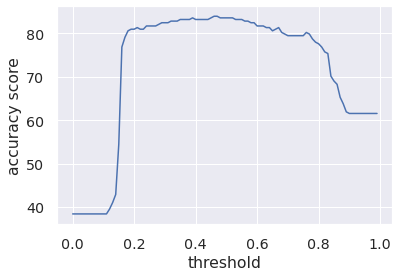

In [64]:
plt.plot(np.arange(0, 1, 0.01), score_array)
plt.xlabel('threshold')
plt.ylabel('accuracy score')
plt.show()

In [65]:
np.argmax(score_array)

46

가장 높은 스코어는 45번째이다. 즉 threshold를 0.45로 잡으면 스코어가 가장 높다는 뜻이다.

In [66]:
prediction = (model.predict_proba(test_X)[:, 1] > 0.45).astype(int)
metrics.accuracy_score(prediction, test_Y)

0.835820895522388

### Linear Support Vector Machine(linear-SVM)

In [67]:
model=svm.SVC(kernel='linear', C=0.1, gamma=0.1)
model.fit(train_X, train_Y)
prediction2 = model.predict(test_X)
print('Accuracy for linear SVM is', metrics.accuracy_score(prediction2, test_Y))

Accuracy for linear SVM is 0.7910447761194029


이것도 위에서처럼 threshold를 찾아본다.

In [68]:
model=svm.SVC(kernel='linear', C=0.1, gamma=0.1, probability=True)
model.fit(train_X, train_Y)

score_array = []
for i in np.arange(0, 1, 0.01):
    prediction = (model.predict_proba(test_X)[:, 1] > i).astype(int)
    temp_score = 100 * metrics.accuracy_score(prediction, test_Y) 
    print(i, 'Accuracy for linear SVM is {:.2f}%'.format(temp_score))
    score_array.append(temp_score)

0.0 Accuracy for linear SVM is 38.43%
0.01 Accuracy for linear SVM is 38.43%
0.02 Accuracy for linear SVM is 38.43%
0.03 Accuracy for linear SVM is 38.43%
0.04 Accuracy for linear SVM is 38.43%
0.05 Accuracy for linear SVM is 38.43%
0.06 Accuracy for linear SVM is 38.43%
0.07 Accuracy for linear SVM is 38.43%
0.08 Accuracy for linear SVM is 38.81%
0.09 Accuracy for linear SVM is 38.81%
0.1 Accuracy for linear SVM is 38.81%
0.11 Accuracy for linear SVM is 38.81%
0.12 Accuracy for linear SVM is 39.55%
0.13 Accuracy for linear SVM is 40.67%
0.14 Accuracy for linear SVM is 40.67%
0.15 Accuracy for linear SVM is 40.67%
0.16 Accuracy for linear SVM is 40.67%
0.17 Accuracy for linear SVM is 41.42%
0.18 Accuracy for linear SVM is 41.42%
0.19 Accuracy for linear SVM is 78.73%
0.2 Accuracy for linear SVM is 78.73%
0.21 Accuracy for linear SVM is 78.73%
0.22 Accuracy for linear SVM is 79.10%
0.23 Accuracy for linear SVM is 79.10%
0.24 Accuracy for linear SVM is 79.10%
0.25 Accuracy for linear SVM

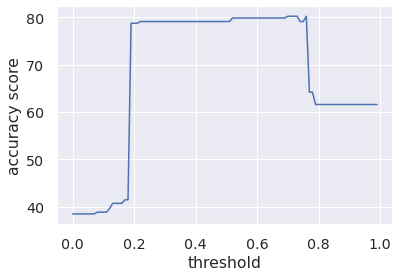

In [69]:
plt.plot(np.arange(0, 1, 0.01), score_array)
plt.xlabel('threshold')
plt.ylabel('accuracy score')
plt.show()

In [70]:
np.argmax(score_array)

70

In [71]:
prediction = (model.predict_proba(test_X)[:, 1] > 0.69).astype(int)
metrics.accuracy_score(prediction, test_Y)

0.7985074626865671

### Logistic Regression

In [72]:
model= LogisticRegression()
model.fit(train_X,train_Y)
prediction3=model.predict(test_X)
print('The accuracy of the Logistic Regression is ', metrics.accuracy_score(prediction3, test_Y))

The accuracy of the Logistic Regression is  0.8022388059701493


In [73]:
score_array = []
for i in np.arange(0, 1, 0.01):
    prediction = (model.predict_proba(test_X)[:, 1] > i).astype(int)
    temp_score = 100 * metrics.accuracy_score(prediction, test_Y) 
    print(i, 'Accuracy for Logistic Regression is {:.2f}%'.format(temp_score))
    score_array.append(temp_score)

0.0 Accuracy for Logistic Regression is 38.43%
0.01 Accuracy for Logistic Regression is 38.81%
0.02 Accuracy for Logistic Regression is 38.81%
0.03 Accuracy for Logistic Regression is 40.30%
0.04 Accuracy for Logistic Regression is 42.16%
0.05 Accuracy for Logistic Regression is 42.16%
0.06 Accuracy for Logistic Regression is 46.27%
0.07 Accuracy for Logistic Regression is 51.12%
0.08 Accuracy for Logistic Regression is 56.72%
0.09 Accuracy for Logistic Regression is 61.57%
0.1 Accuracy for Logistic Regression is 62.69%
0.11 Accuracy for Logistic Regression is 64.93%
0.12 Accuracy for Logistic Regression is 68.28%
0.13 Accuracy for Logistic Regression is 68.28%
0.14 Accuracy for Logistic Regression is 68.66%
0.15 Accuracy for Logistic Regression is 69.03%
0.16 Accuracy for Logistic Regression is 70.15%
0.17 Accuracy for Logistic Regression is 71.27%
0.18 Accuracy for Logistic Regression is 71.64%
0.19 Accuracy for Logistic Regression is 71.64%
0.2 Accuracy for Logistic Regression is 73

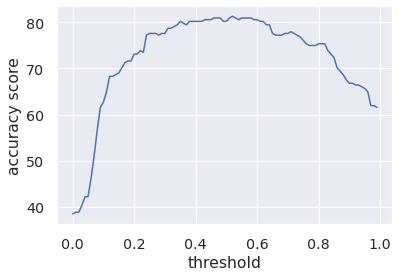

In [74]:
plt.plot(np.arange(0, 1, 0.01), score_array)
plt.xlabel('threshold')
plt.ylabel('accuracy score')
plt.show()

In [75]:
np.argmax(score_array)

52

### Decision Tree

In [76]:
model = DecisionTreeClassifier()
model.fit(train_X, train_Y)
prediction4 = model.predict(test_X)
print('The accuracy of the Decision Tree is',
      metrics.accuracy_score(prediction4, test_Y))

The accuracy of the Decision Tree is 0.7947761194029851


In [77]:
score_array = []
for i in np.arange(0, 1, 0.01):
    prediction = (model.predict_proba(test_X)[:, 1] > i).astype(int)
    temp_score = 100 * metrics.accuracy_score(prediction, test_Y) 
    print(i, 'Accuracy for Logistic Regression is {:.2f}%'.format(temp_score))
    score_array.append(temp_score)

0.0 Accuracy for Logistic Regression is 55.60%
0.01 Accuracy for Logistic Regression is 55.60%
0.02 Accuracy for Logistic Regression is 55.60%
0.03 Accuracy for Logistic Regression is 55.60%
0.04 Accuracy for Logistic Regression is 59.33%
0.05 Accuracy for Logistic Regression is 59.33%
0.06 Accuracy for Logistic Regression is 63.06%
0.07 Accuracy for Logistic Regression is 63.06%
0.08 Accuracy for Logistic Regression is 63.06%
0.09 Accuracy for Logistic Regression is 63.06%
0.1 Accuracy for Logistic Regression is 66.42%
0.11 Accuracy for Logistic Regression is 69.78%
0.12 Accuracy for Logistic Regression is 70.52%
0.13 Accuracy for Logistic Regression is 70.52%
0.14 Accuracy for Logistic Regression is 70.52%
0.15 Accuracy for Logistic Regression is 70.52%
0.16 Accuracy for Logistic Regression is 73.13%
0.17 Accuracy for Logistic Regression is 77.61%
0.18 Accuracy for Logistic Regression is 77.61%
0.19 Accuracy for Logistic Regression is 77.61%
0.2 Accuracy for Logistic Regression is 77

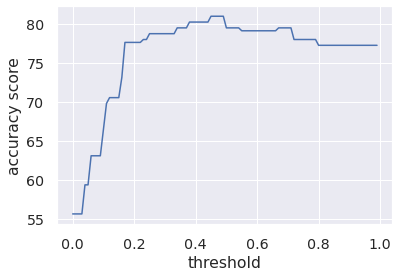

In [78]:
plt.plot(np.arange(0, 1, 0.01), score_array)
plt.xlabel('threshold')
plt.ylabel('accuracy score')
plt.show()

In [79]:
np.argmax(score_array)

45

### K-Nearest Neighbours(KNN)

In [80]:
model = KNeighborsClassifier()
model.fit(train_X, train_Y)
prediction5 = model.predict(test_X)
print('The accuracy of the KNN is',
     metrics.accuracy_score(prediction5, test_Y))

The accuracy of the KNN is 0.7761194029850746


Now the accuracy for the KNN model changes as we change the values for **n_neighbours** attribute. The default value is **5**. Lets check the accuracies over various of n_neighbours.

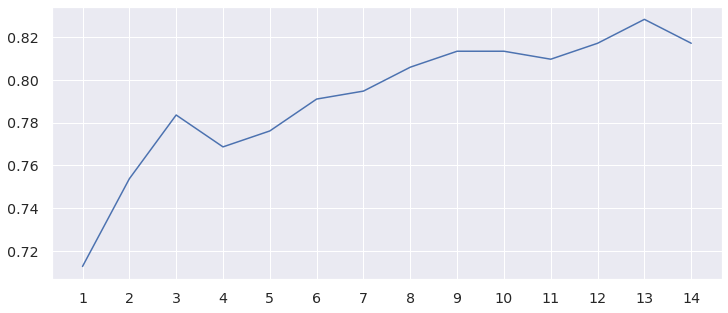

Accuracies for different values of n are: [0.71268657 0.75373134 0.78358209 0.76865672 0.7761194  0.79104478
 0.79477612 0.80597015 0.81343284 0.81343284 0.80970149 0.81716418
 0.82835821 0.81716418] with the max value as  0.8283582089552238


In [81]:
a_range = range(1, 15)
a_index=list(a_range)
a=pd.Series()
a_range
for i in list(a_range):
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(train_X, train_Y)
    prediction = model.predict(test_X)
    a = a.append(pd.Series(metrics.accuracy_score(prediction, test_Y)))
plt.plot(a_index, a)
plt.xticks(a_range)
fig = plt.gcf()
fig.set_size_inches(12, 5)
plt.show()
print('Accuracies for different values of n are:', a.values, 'with the max value as ', a.values.max())

### Gaussian Naive Bayes

In [82]:
model = GaussianNB()
model.fit(train_X, train_Y)
prediction6 = model.predict(test_X)
print('The accuracy of the NaiveBayes is ', 
     metrics.accuracy_score(prediction6, test_Y))

The accuracy of the NaiveBayes is  0.7985074626865671


### Random Forests

In [83]:
model = RandomForestClassifier(n_estimators=100)
model.fit(train_X, train_Y)
prediction7 = model.predict(test_X)
print('The accuracy of the Random Forests is ', metrics.accuracy_score(prediction7, test_Y))

The accuracy of the Random Forests is  0.8097014925373134


The accuracy of a model is not the only factor that determines the robustness of the classifier. Let's say that a classifier is trained over a training data and tested over the test data and it scores an accuracy of 90%.

Now this seems to be very good accuracy for a classifier, but can we confirm that it will be 90% for all the new test sets that come over??. The answer is **No**, because we can't determine which all instances will the classifier will use to train itself. As the training and testing data changes, the accuracy will also change. It may increase or decrease. This is known as **model variance**.

To overcome this and get a generalized model, we use **Cross Validation**.

## Cross Validation

Many a times, the data is imbalanced, i.e there may be a high number of class1 instances but less number of other class instances. Thus we should train and test our algorithm on each and every instance of the datatset. Then we can take an average of all the noted accuracies over the dataset.

1) The K-Fold Cross Validation works by first dividing the dataset into k-subsets.

2) Let's say we divide the dataset into (k=5) parts. We reserve 1 part for testing and train the algorithm over the 4 parts.

3) We continue the process by changing the testing part in each iteration and training the algorithm over the other parts. The accuracies and errors are then averaged to get a average accuracy of the algorithm.

This is called K-Fold Cross Validation.

4) An algorithm may underfit over a dataset for some training data and sometimes also overfit the data for other training set. Thus with cross-validation, we can achieve a generalised model.

In [84]:
from sklearn.model_selection import KFold # for K-fold cross validation
from sklearn.model_selection import cross_val_score # score evaluation
from sklearn.model_selection import cross_val_predict # prediction
kfold = KFold(n_splits=10, random_state=22) # k=10, split the data into 10 equal parts
xyz = []
accuracy = []
std = []
classifiers=['Linear Svm', 'Radial Svm', 'Logistic Regressin',
             'KNN', 'Decision Tree', 'Naive Bayes', 'Random Forest']
models = [svm.SVC(kernel='linear'),
          svm.SVC(kernel='rbf'),
          LogisticRegression(),
          KNeighborsClassifier(n_neighbors=9),
          DecisionTreeClassifier(), 
          GaussianNB(), 
          RandomForestClassifier(n_estimators=100)]
for model in models:
    cv_result = cross_val_score(model,X,Y, cv = kfold, scoring = 'accuracy')
    xyz.append(cv_result.mean())
    std.append(cv_result.std())
    accuracy.append(cv_result)
new_models_dataframe2 = pd.DataFrame({'CV Mean':xyz,'Std':std}, index=classifiers)
new_models_dataframe2

,CV Mean,Std
Linear Svm,0.790087,0.040990
Radial Svm,0.832772,0.036735
Logistic Regressin,0.797990,0.022922
KNN,0.796891,0.047083
Decision Tree,0.811498,0.036872
Naive Bayes,0.791311,0.031697
Random Forest,0.813758,0.041712


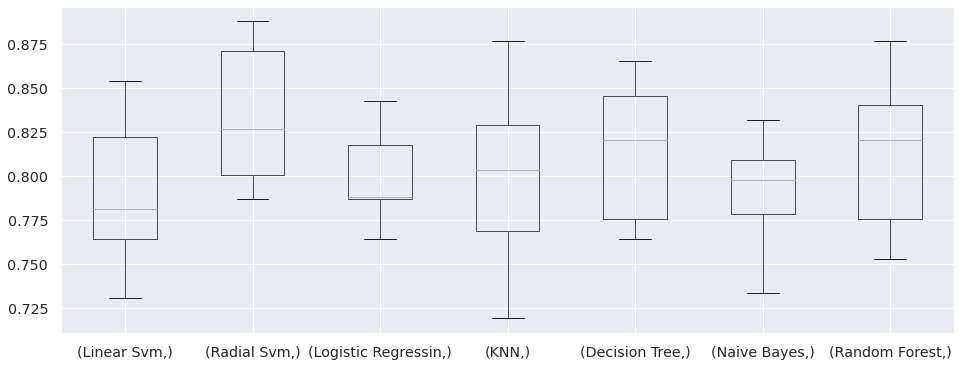

In [85]:
plt.subplots(figsize=(16,6))
box=pd.DataFrame(accuracy, index=[classifiers])
box.T.boxplot()
plt.show()

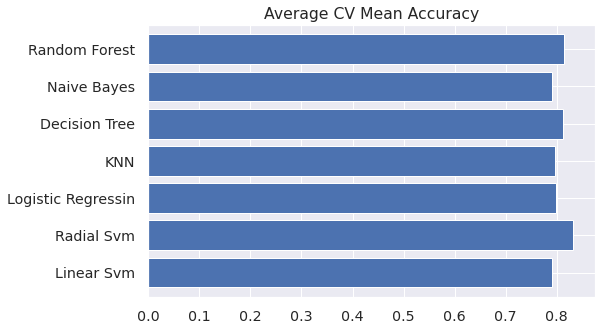

In [86]:
new_models_dataframe2['CV Mean'].plot.barh(width=0.8)
plt.title('Average CV Mean Accuracy')
fig = plt.gcf()
fig.set_size_inches(8,5)
plt.show()

The classification accuracy can be sometimes misleading due to imbalance. We can get a summarized result with the help of confusion matrix, which shows where did the model go wrong, or which class did the model predict wrong.

## Confusion Matrix

It gives the number of correct and incorrect classifications made by the classifier.

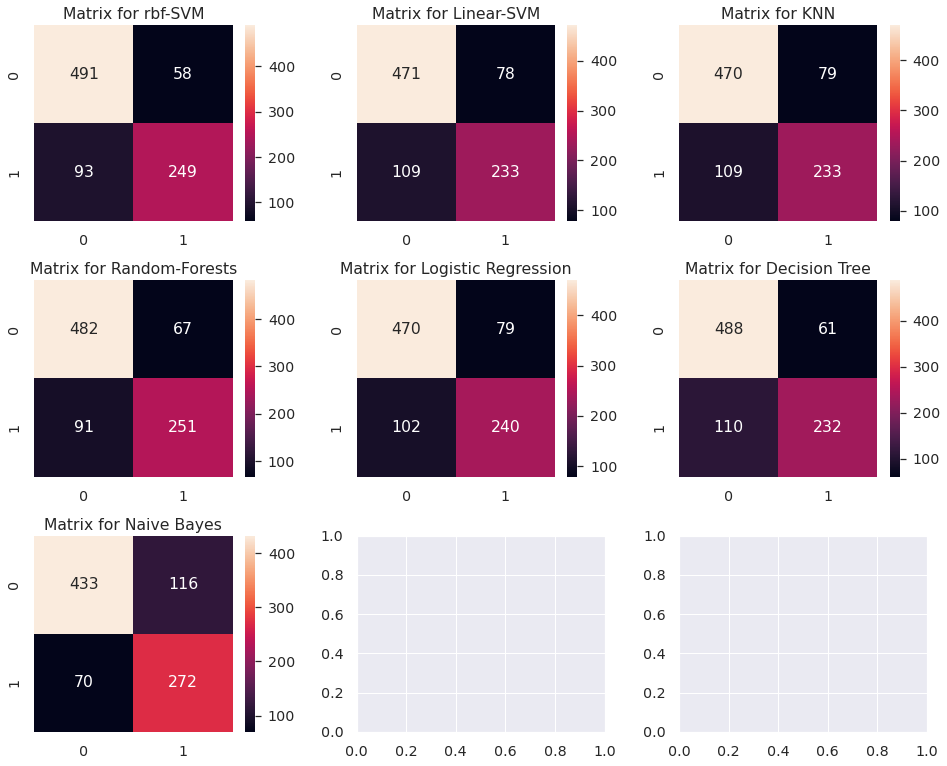

In [87]:
f,ax = plt.subplots(3, 3, figsize=(16,13))
y_pred = cross_val_predict(svm.SVC(kernel='rbf'),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y, y_pred), ax=ax[0,0], annot=True, fmt='2.0f')
ax[0,0].set_title('Matrix for rbf-SVM')

y_pred = cross_val_predict(svm.SVC(kernel='linear'),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y, y_pred), ax=ax[0,1], annot=True,fmt='2.0f')
ax[0,1].set_title('Matrix for Linear-SVM')

y_pred = cross_val_predict(KNeighborsClassifier(n_neighbors=9),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y, y_pred), ax=ax[0,2], annot=True, fmt='2.0f')
ax[0,2].set_title('Matrix for KNN')

y_pred = cross_val_predict(RandomForestClassifier(n_estimators=100),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y, y_pred), ax=ax[1,0], annot=True, fmt='2.0f')
ax[1,0].set_title('Matrix for Random-Forests')

y_pred = cross_val_predict(LogisticRegression(),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y, y_pred), ax=ax[1,1], annot=True, fmt='2.0f')
ax[1,1].set_title('Matrix for Logistic Regression')

y_pred = cross_val_predict(DecisionTreeClassifier(),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y, y_pred), ax=ax[1,2], annot=True, fmt='2.0f')
ax[1,2].set_title('Matrix for Decision Tree')

y_pred = cross_val_predict(GaussianNB(),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y, y_pred), ax=ax[2,0], annot=True, fmt='2.0f')
ax[2,0].set_title('Matrix for Naive Bayes')

plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()

### Interpreting Confusion Matrix
The left diagonal shows the nunber of correct predictions made for each class while the right diagonal shows the number of wrong predictions made. Let's consider the first plot for rbf-SVM:

1) The no. of correct predictions are **491(for dead) + 247(for survived)** with the mean CV accuracy being **(491+247)/891=82.8%** which we did get earlier.

2) **Errors**--> Wrongly Classified 58 dead people as survived and 95 survived as dead. Thus it has made more mistakes by predicting dead as survived.

By looking at all the matrices, we can say that rbf-SVM has a higher chance in correctly predicting dead passengers but NaiveBayes has a higher chance in correctly predicting passengers who survived.

### Hyper-Parameters Tuning

The machine learning models are like a Black-Box. There are some default parameter values for this Black-Box, which we can tune or change to get a better model. Like the C and gamma in the SVM model and similarly different parameters for different classifiers, are called the hyper-parameters, which we can tune to change the learning rate of the algorithm and get a better model. This is known as Hyper-Parameter Tuning.

We will tune the hyper-parameters for the 2 best classfiers. i.e the SVM and RandomForests.

보통 대회에서는 하이퍼파라미터 튜닝은 나중에 한다. 피쳐를 찾는 것이 먼저다.  

파라미터 튜닝 방법은 크게 4가지가 있다.

- Manual tuning
- Gridsearch 
- Randomized search
- Baysian optimazation

그리드 서치는 정말 세세하게 훑을 수 있지만 파라미터도 많고 데이터가 많아질 수록 시간이 너무 많이 걸려서 Randomized search를 사용하는 것이 낫다. (이유한)


### SVM

In [88]:
from sklearn.model_selection import GridSearchCV

C=[0.05,0.1,0.2,0.3,0.25,0.4,0.5,0.6,0.7,0.8,0.9,1]
gamma=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
kernel=['rbf','linear']
hyper={'kernel':kernel,'C':C,'gamma':gamma}
gd=GridSearchCV(estimator=svm.SVC(),param_grid=hyper,verbose=True)
gd.fit(X,Y)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 1200 out of 1200 | elapsed:   20.8s finished


GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.05, 0.1, 0.2, 0.3, 0.25, 0.4, 0.5, 0.6, 0.7,
                               0.8, 0.9, 1],
                         'gamma': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,
                                   1.0],
                         'kernel': ['rbf', 'linear']},
             verbose=True)

In [89]:
print(gd.best_score_)
print(gd.best_estimator_)

0.8316238779737619
SVC(C=0.7, gamma=0.1)


### Random Forests

In [90]:
n_estimators = range(100, 1000, 100)
hyper={'n_estimators': n_estimators}
gd=GridSearchCV(estimator=RandomForestClassifier(random_state=0), 
                param_grid=hyper, verbose=True)
gd.fit(X, Y)
print(gd.best_score_)
print(gd.best_estimator_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  45 out of  45 | elapsed:   37.4s finished


0.8182223338145753
RandomForestClassifier(n_estimators=400, random_state=0)


In [91]:
# 제일 성능이 좋았던 파라미터을 뽑아서 변수화한다.
best_params = gd.best_estimator_.get_params()

# 모델을 생성할 때 변수를 언패킹해서 넣어준다.
model = RandomForestClassifier(**best_params)

The best score for Rbf-SVM is **82.82% with C=0.4 and gamma=0.3**. For RandomForest, score is abt **81.9% with n_estimators=300**.

## Ensembling

Ensembling is a good way to increase the accuracy or performance of a model. In simple words, it is the combination of various simple models to create a single powerful model. 

Lets say we want to buy a phone and ask many people about it based on various parameters. So then we can make a strong judgement about a single product after anaysing all different parameters. This is **Ensembling**, which improves the stability of the model. Ensembling can be done in ways like:

1) Voting Classifier

2) Bagging

3) Boosting.

캐글에서 점수를 높이는 방법 중 핵심이다. 

## Voting Classifier

It is the simplest way of combining predictions from many different simple machine learning models. It gives an average prediction result based on the prediction of all the submodels. The submodels or the basemodels are all of different types.

보팅 방식으로 soft와 hard가 있다. 
- soft : 예를들어 하나에 샘플에 대해 1번 모델은 50%, 2번 모델은 60%, 3번 모델은 70%라는 확률을 냈다면 거기서 가장 높은 70%모델의 예측치를 따라간다. 

- hard : 위와 같은 상황에서 3모델 다 50%이상의 예측치를 내고 있으니까 만장일치가 되고 만약 다른 상황에서 1번은 30%, 2번은 20%, 3번은 80%라면 두 모델은 아니라고 예측하니까 다수결로 아니라는 결과를 내게된다.

In [92]:
from sklearn.ensemble import VotingClassifier

ensemble_lin_rbf = VotingClassifier(estimators=[('KNN', KNeighborsClassifier(n_neighbors=10)),
                                                ('RBF', svm.SVC(probability=True, kernel='rbf',C=0.4, gamma=0.3)), 
                                                ('rFor', RandomForestClassifier(n_estimators=300, random_state=0)), 
                                                ('LR', LogisticRegression(C=0.05)), 
                                                ('DT', DecisionTreeClassifier(random_state=0)), 
                                                ('NB', GaussianNB()), 
                                                ('svm', svm.SVC(kernel='linear', probability=True))], 
                                    voting='soft').fit(train_X, train_Y)
print('The accuracy for ensembled model is:', ensemble_lin_rbf.score(test_X, test_Y))
cross=cross_val_score(ensemble_lin_rbf,X,Y,cv=10,scoring='accuracy')
print('The cross validated score is', cross.mean())

The accuracy for ensembled model is: 0.8283582089552238
The cross validated score is 0.823820224719101


유한님은 보팅은 잘 사용하지 않는다. 보통 probability를 합쳐서 사용하고 결과값을 가지고 보팅하지 않는다.

## Bagging

Bagging is a general ensemble method. It works by applying similar classifiers on small partitions of the dataset and then taking the average of all the predictions. Due to the averaging, there is reduction in variance. Unlike Voting Classifier, Bagging makes use of similar classifiers

### Bagged KNN
Bagging works best with models with high variance. An example for this can be Decision Tree or Random Forests. We can use KNN with small value of **n_neighbours**, as small value of n_neighbours.

선형적이지 않은 디시전트리나 랜덤포레스트는 새로운 데이터에 맞춰 형태가 크게 변하게 된다. 이런 특성을 high variance라고 한다. overfit이 잘되는 모델의 일반성 향상에 도움을 준다.

In [93]:
from sklearn.ensemble import BaggingClassifier
model = BaggingClassifier(base_estimator=KNeighborsClassifier(n_neighbors=3), 
                          random_state=0, n_estimators=700)
model.fit(train_X, train_Y)
prediction = model.predict(test_X)
print('The accuracy for bagged KNN is:',metrics.accuracy_score(prediction, test_Y))
result = cross_val_score(model,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for bagged KNN is:', result.mean())

The accuracy for bagged KNN is: 0.8022388059701493
The cross validated score for bagged KNN is: 0.8103995006242197


### Bagged DecisionTree

In [94]:
model = BaggingClassifier(base_estimator=DecisionTreeClassifier(), 
                          random_state=0, n_estimators=100)
model.fit(train_X, train_Y)
prediction = model.predict(test_X)
print('The accuracy for bagged Decision Tree is:', 
      metrics.accuracy_score(prediction, test_Y))
result = cross_val_score(model,X,Y,cv=10,scoring='accuracy')
print('The cross validation score for bagged Decision Tree is:', 
      result.mean())

The accuracy for bagged Decision Tree is: 0.8171641791044776
The cross validation score for bagged Decision Tree is: 0.8171410736579275


## Boosting

Boosting is an ensembling technique which uses sequntial learning of classifiers. It is a step by step enhancement of a weak model. Boosting works as follows:

A model is first trained on the complete dataset. Now the model will get some instances right while some wrong. Now in the next iteration, the learner will focus more on the wrongly predicted instances or give more weight to it. Thus it will try to predict the wrong instance correctly. Now this iterative process continous, and new classifiers are added to the model until the limit is reached on the accuracy.

### AdaBoost(Adaptive Boosting)

The weak learner or estimator in this case is a Decision Tree. But we can change the default base_estimator to any algorithm of our choice. 

In [95]:
# n_estimators=200은 200개의 클래시파이어를 만들어나간다는 뜻이다.
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier(n_estimators=200, random_state=0, 
                         learning_rate=0.1)
result = cross_val_score(ada,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for AdaBoost is:', result.mean())

The cross validated score for AdaBoost is: 0.8271660424469414


### Stochastic Gradient Boosting

Here too the weak learner is a Decision Tree.

In [96]:
from sklearn.ensemble import GradientBoostingClassifier
grad = GradientBoostingClassifier(n_estimators=500, 
                                  random_state=0, 
                                  learning_rate=0.1)
result = cross_val_score(grad,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for Gradient Boosting is:', result.mean())

The cross validated score for Gradient Boosting is: 0.817116104868914


### XGBoost

In [97]:
import xgboost as xg
xgboost=xg.XGBClassifier(n_estimators=900,learning_rate=0.1)
result=cross_val_score(xgboost,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for XGBoost is:',result.mean())

[02:00:35] WARNING: ../src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[02:00:37] WARNING: ../src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[02:00:41] WARNING: ../src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[02:00:43] WARNING: ../src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old be

We got the highest accuracy for AdaBoost. We will try to increase it with Hyper-Parameter Tuning.

### Hyper-Parameter Tuning for AdaBoost

In [98]:
n_estimators=list(range(100,1100,100))
learn_rate=[0.05,0.1,0.2,0.3,0.25,0.4,0.5,0.6,0.7,0.8,0.9,1]
hyper={'n_estimators':n_estimators,'learning_rate':learn_rate}
gd=GridSearchCV(estimator=AdaBoostClassifier(),param_grid=hyper,verbose=True)
gd.fit(X,Y)
print(gd.best_score_)
print(gd.best_estimator_)

Fitting 5 folds for each of 120 candidates, totalling 600 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 600 out of 600 | elapsed:  9.7min finished


0.8305128366078716
AdaBoostClassifier(learning_rate=0.05, n_estimators=200)


The maximum accuracy we can get with AdaBoost is **82.9% with n_estimators=100 and learning_rate=0.1**.

### Confusion Matrix for the Best Model

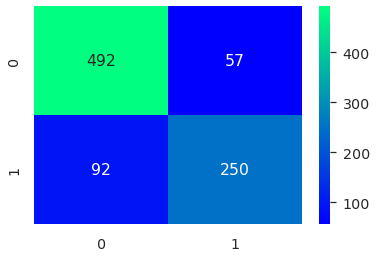

In [99]:
ada = AdaBoostClassifier(n_estimators=100, random_state=0, 
                        learning_rate=0.1)
result = cross_val_predict(ada,X,Y,cv=10)
sns.heatmap(confusion_matrix(Y, result), 
            cmap='winter', annot=True, fmt='2.0f')
plt.show()

## Feature Importance

[02:10:48] WARNING: ../src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


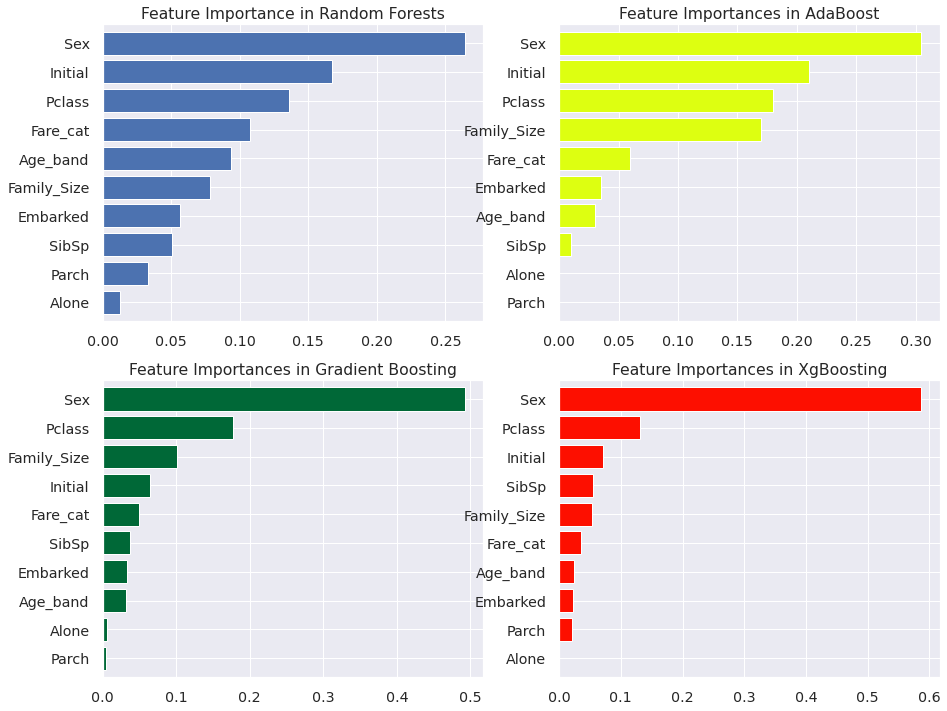

In [100]:
f,ax = plt.subplots(2,2,figsize=(15,12))
model = RandomForestClassifier(n_estimators=500, random_state=0)
model.fit(X, Y)
pd.Series(model.feature_importances_,
          X.columns).sort_values(ascending=True).plot.barh(width=0.8,ax=ax[0,0])
ax[0,0].set_title('Feature Importance in Random Forests')

model = AdaBoostClassifier(n_estimators=200, learning_rate=0.05, 
                           random_state=0)
model.fit(X,Y)
pd.Series(model.feature_importances_,
          X.columns).sort_values(ascending=True).plot.barh(width=0.8,
                                                           ax=ax[0,1], 
                                                           color='#ddff11')
ax[0,1].set_title('Feature Importances in AdaBoost')

model = GradientBoostingClassifier(n_estimators=500, learning_rate=0.1, random_state=0)
model.fit(X, Y)
pd.Series(model.feature_importances_,
          X.columns).sort_values(ascending=True).plot.barh(width=0.8, 
                                                           ax=ax[1,0], 
                                                           cmap='RdYlGn_r')
ax[1,0].set_title('Feature Importances in Gradient Boosting')

model = xg.XGBClassifier(n_estimators=900, learning_rate=0.1)
model.fit(X,Y)
pd.Series(model.feature_importances_,
          X.columns).sort_values(ascending=True).plot.barh(width=0.8, 
                                                           ax=ax[1,1], 
                                                           color='#FD0F00')
ax[1,1].set_title('Feature Importances in XgBoosting')
plt.show()

We can see the important features for various classifiers like RandomForests, AdaBoost,etc.

피쳐의 중요도는 모델마다 편차가 크다. 그래서 보통 피쳐 중요도를 잴 때는 랜덤 포레스트를 많이 사용한다. 아니면 지금처럼 여러 모델마다 중요도를 구하고 평균을 내서 중요도를 파악할 수도 있다. 이렇게 파악해서 피쳐를 더하거나 뺄 수있다. 지금 구한 중요도는 모델마다의 하나의 가설이다. 모델마다 정확도를 올리기 위해서 학습하다 보니까 얻어진 중요도다. 

### Observations:
1) Some of the common important features are Initail,Fare_cat,Pclass,Family_Size.

2) The Sex feature doesn't seem to give any importance, which is shocking as we had seen earlier that Sex combined with Pclass was giving a very good differentiating factor. Sex looks to be important only in RandomForests.

However, we can see the feature Initial, which is at the top in many classifiers. We had already seen the positive correlation between Sex and Initial, so they both refer to the gender.

3) Similarly the Pclass and Fare_cat refer to the status of the passengers and Family_Size with Alone,Parch and SibSp.


I hope all of you did gain insights to Machine Learning. Some other great notebooks for Machine Learning are: 

1) For Python: Pytanic by Heads and Tails

2) For Python: Introduction to Ensembling/Stacking by Anistropic